In [337]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import os
import numpy as np
from scipy import signal

In [338]:
path = "PID_data"

In [339]:
def load_pid_data(num, heater_types=['f', 'n', 'nf']):
    """
    Load CSV data for a given PID number from multiple heater types.
    Extracts initial temperature from folder name and calculates setpoint and error.
    
    Args:
        num: The PID number to load (e.g., 1, 123, 1234)
        heater_types: List of heater types to load (default: ['f', 'n', 'nf'])
    
    Returns:
        dict: Dictionary with heater types as keys and DataFrames as values with setpoint and error columns
    """
    data = {}
    base_path = Path(path)
    
    for heater_type in heater_types:
        # Find folders matching the pattern: "{num} {heater_type} *"
        matching_folders = list(base_path.glob(f"{num} {heater_type} *"))
        
        if not matching_folders:
            print(f"Warning: No folder found for {num} {heater_type}")
            continue
        
        folder = matching_folders[0]  # Take the first matching folder
        folder_name = folder.name
        
        # Extract initial temperature from folder name: "{num} {heater_type} {initial_temp}"
        try:
            parts = folder_name.rsplit(' ', 1)
            initial_temp = float(parts[-1])
            setpoint = initial_temp + 3.0  # Setpoint is initial temp + 3°C
        except (ValueError, IndexError):
            print(f"Warning: Could not extract temperature from folder name: {folder_name}")
            continue
        
        # Find CSV files in the folder
        csv_files = list(folder.glob("*.csv"))
        
        if not csv_files:
            print(f"Warning: No CSV found in {folder}")
            continue
        
        csv_file = csv_files[0]  # Take the first CSV
        
        # Load the CSV
        df = pd.read_csv(csv_file)
        df['time'] = pd.to_datetime(df['time'])
        df['setpoint'] = setpoint
        
        # Discard datapoints before heater turns on (Heater Ch 1 != 0)
        if 'Heater Ch 1' in df.columns:
            heater_on_idx = (df['Heater Ch 1'] != 0).idxmax()
            if df.loc[heater_on_idx, 'Heater Ch 1'] != 0:  # Check if heater actually turns on
                df = df.loc[heater_on_idx:].reset_index(drop=True)
        
        # Calculate error: actual temperature - setpoint
        df['error'] = df['Thermo Ch 5'] - setpoint
        
        data[heater_type] = df
        print(f"Loaded: {csv_file.name} (Initial: {initial_temp}°C, Setpoint: {setpoint}°C)")
    
    return data

In [340]:
def plot_combined_data(num, columns=['Thermo Ch 5', 'Heater Ch 1'], figsize=(14, 6)):
    """
    Load and plot combined data from three heater types in the same graph.
    Uses error (temperature - setpoint) instead of absolute temperature.
    
    Args:
        num: The PID number to analyze
        columns: List of columns to plot (default: ['Thermo Ch 5', 'Heater Ch 1'])
        figsize: Figure size for the plot
    """
    # Load data from all three heater types
    data = load_pid_data(num)
    
    if not data:
        print(f"No data found for PID number {num}")
        return
    
    # Create subplots for each column
    fig, axes = plt.subplots(len(columns), 1, figsize=figsize)
    if len(columns) == 1:
        axes = [axes]
    
    # Define colors for each heater type
    colors = {'f': '#1f77b4', 'n': '#ff7f0e', 'nf': '#2ca02c'}
    
    for idx, column in enumerate(columns):
        ax = axes[idx]
        
        for heater_type, df in data.items():
            if column in df.columns:
                # Convert time to seconds from start for better x-axis
                start_time = df['time'].min()
                time_seconds = (df['time'] - start_time).dt.total_seconds()
                
                # Use error if column is Thermo Ch 5, else use absolute value
                if column == 'Thermo Ch 5':
                    y_data = df['error']
                    y_label = f"{column} Error (°C)"
                else:
                    y_data = df[column]
                    y_label = column
                
                ax.plot(
                    time_seconds,
                    y_data,
                    label=f"{heater_type}",
                    color=colors.get(heater_type, None),
                    alpha=0.8,
                    linewidth=2
                )
        
        ax.set_ylabel(y_label, fontsize=11)
        ax.set_xlabel('Time (seconds)', fontsize=11)
        ax.legend(loc='best')
        ax.grid(True, alpha=0.3)
        
        # Add zero line for error plot
        if 'Error' in y_label:
            ax.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5, label='Setpoint')
        
        ax.set_title(f'PID {num} - {y_label if "Error" in y_label else column}', fontsize=12, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    return data

In [ ]:
def calculate_overshoot(df, column='error'):
    """
    Calculate maximum overshoot from setpoint error.
    Positive error values mean the temperature is above setpoint.
    
    Args:
        df: DataFrame with the data
        column: Column to analyze (default: 'error')
    
    Returns:
        float: Maximum overshoot value in °C
    """
    if column not in df.columns or len(df) == 0:
        return 0.0
    
    values = df[column].values
    positive_values = values[values > 0]
    return float(np.max(positive_values)) if len(positive_values) > 0 else 0.0


def calculate_undershoot(df, column='error'):
    """
    Calculate maximum undershoot after the overshoot peak.
    Negative error values mean the temperature is below setpoint.
    
    Args:
        df: DataFrame with the data
        column: Column to analyze (default: 'error')
    
    Returns:
        float: Maximum undershoot value in °C (absolute magnitude)
    """
    if column not in df.columns or len(df) == 0:
        return 0.0
    
    values = df[column].values
    positive_indices = np.where(values > 0)[0]
    if len(positive_indices) == 0:
        return 0.0
    
    overshoot_peak_idx = positive_indices[np.argmax(values[positive_indices])]
    values_after_overshoot = values[overshoot_peak_idx + 1:]
    negative_values_after = values_after_overshoot[values_after_overshoot < 0]
    return float(abs(np.min(negative_values_after))) if len(negative_values_after) > 0 else 0.0


def calculate_steady_state_time(df, column='error', tolerance=0.02):
    if column not in df.columns or len(df) == 0:
        return 0.0

    values = df[column].values

    if pd.api.types.is_datetime64_any_dtype(df['time']):
        time_seconds = (df['time'] - df['time'].iloc[0]).dt.total_seconds().values
    else:
        time_seconds = (df['time'] - df['time'].iloc[0]).values

    # Find search start: after undershoot (which follows overshoot), or after peak
    positive_indices = np.where(values > tolerance)[0]  # above band = overshoot
    search_start_idx = 0

    if len(positive_indices) > 0:
        overshoot_peak_idx = positive_indices[np.argmax(values[positive_indices])]
        values_after = values[overshoot_peak_idx + 1:]
        negative_after = np.where(values_after < -tolerance)[0]  # below band = undershoot
        if len(negative_after) > 0:
            undershoot_idx = overshoot_peak_idx + 1 + negative_after[np.argmin(values_after[negative_after])]
            search_start_idx = undershoot_idx + 1
        else:
            search_start_idx = overshoot_peak_idx + 1

    # Use 0 as band center for error signal
    band_min, band_max = -tolerance, tolerance

    # O(n): find last violation after search_start_idx
    violations = np.where((values < band_min) | (values > band_max))[0]
    violations = violations[violations >= search_start_idx]

    if len(violations) == 0:
        # Already settled at search_start_idx
        return float(time_seconds[min(search_start_idx, len(time_seconds) - 1)])

    last_violation = violations[-1]
    if last_violation + 1 >= len(values):
        return float(time_seconds[-1])  # Never fully settled

    return float(time_seconds[last_violation + 1])

def calculate_snr(df, column='error', tolerance=0.02):
    """
    Calculate Signal-to-Noise Ratio (SNR) in dB.
    Uses the settling time from calculate_steady_state_time() to define the start of steady state.
    Measures how much of the transient response stands out from the steady-state noise.
    
    Args:
        df: DataFrame with the data
        column: Column to analyze (default: 'error')
        tolerance: Tolerance band in °C (±tolerance)
    
    Returns:
        float: SNR in dB (higher = better)
    """
    if column not in df.columns or len(df) == 0:
        return 0.0
    
    values = df[column].values
    time_seconds = (df['time'] - df['time'].iloc[0]).dt.total_seconds().values
    
    # Use calculate_steady_state_time to find where steady state begins
    settling_time = calculate_steady_state_time(df, column, tolerance)
    
    # Find the index corresponding to the settling time
    steady_state_start_idx = np.searchsorted(time_seconds, settling_time)
    
    steady_state_values = values[steady_state_start_idx:]
    noise_level = np.std(steady_state_values) if len(steady_state_values) > 0 else 1e-6
    transient_values = values[:steady_state_start_idx]
    signal_level = np.std(transient_values) if len(transient_values) > 0 else 1e-6
    
    snr_db = 20 * np.log10((signal_level + 1e-10) / (noise_level + 1e-10))
    return float(snr_db)

Loaded: 2 f 16.78_2026-05-06T10_45_50.690Z.csv (Initial: 16.78°C, Setpoint: 19.78°C)
Loaded: 2 n 16.80_2026-05-06T11_17_11.442Z.csv (Initial: 16.8°C, Setpoint: 19.8°C)
Loaded: 2 nf 16.34_2026-05-06T10_13_57.141Z.csv (Initial: 16.34°C, Setpoint: 19.34°C)


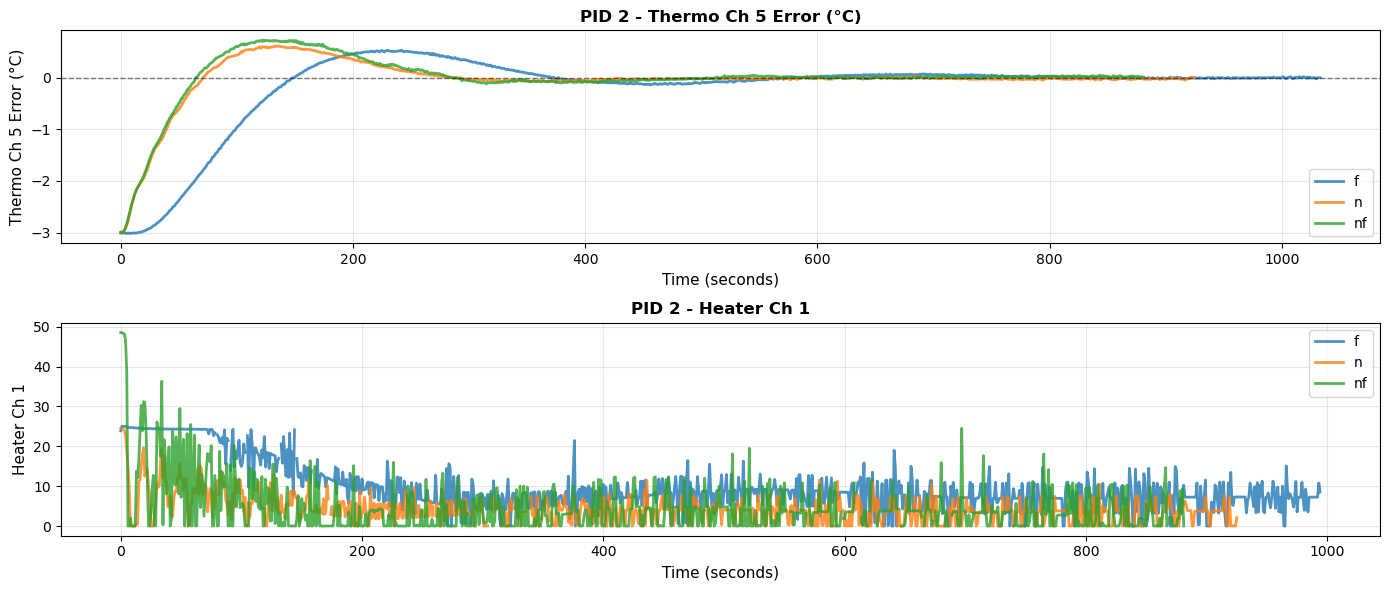

In [342]:
peltiers = "2"
data_1 = plot_combined_data(peltiers)

In [343]:
def analyze_thermal_response(num, heater_types=['f', 'n', 'nf'], column='error', tolerance=0.02):
    """
    Comprehensive thermal analysis for all heater types using error from setpoint.
    
    Args:
        num: PID number to analyze
        heater_types: List of heater types
        column: Column to analyze (default: 'error')
        tolerance: Absolute tolerance band in °C (default: 0.02)
    
    Returns:
        DataFrame: Summary statistics for all heater types
    """
    data = load_pid_data(num, heater_types)
    
    results = []
    
    for heater_type, df in data.items():
        values = df[column].values
        time_values = (df['time'] - df['time'].iloc[0]).dt.total_seconds().values
        
        # Find steady state region
        max_idx = np.argmax(values)
        if max_idx < len(values) - 1:
            min_idx = max_idx + np.argmin(values[max_idx:])
        else:
            min_idx = max_idx
        
        search_start = min_idx
        final_value = values[-1]
        band_min = final_value - tolerance
        band_max = final_value + tolerance
        
        # Find steady state start index
        steady_state_start_idx = len(values)
        for i in range(search_start, len(values)):
            remaining_values = values[i:]
            if np.all((remaining_values >= band_min) & (remaining_values <= band_max)):
                steady_state_start_idx = i
                break
        
        # Extract steady state data
        steady_state_values = values[steady_state_start_idx:]
        steady_state_time = time_values[steady_state_start_idx:]
        
        # Find min and max within steady state
        if len(steady_state_values) > 0:
            min_error = np.min(steady_state_values)
            max_error = np.max(steady_state_values)
            min_idx_ss = np.argmin(steady_state_values)
            max_idx_ss = np.argmax(steady_state_values)
            min_time = steady_state_time[min_idx_ss]
            max_time = steady_state_time[max_idx_ss]
            
            # Calculate deviation metrics
            peak_to_peak = max_error - min_error
            # Max absolute deviation from final value
            max_abs_deviation = max(abs(max_error - final_value), abs(min_error - final_value))
        else:
            min_error = final_value
            max_error = final_value
            min_time = time_values[-1]
            max_time = time_values[-1]
            peak_to_peak = 0
            max_abs_deviation = 0
        
        analysis = {
            'Heater Type': heater_type,
            'Max Overshoot': calculate_overshoot(df, column),
            'Max Undershoot': calculate_undershoot(df, column),
            'Settling Time (s)': calculate_steady_state_time(df, column, tolerance),
            'SNR (dB)': calculate_snr(df, column, tolerance),
            'Initial Error': df[column].iloc[0],
            'Final Error': df[column].iloc[-1],
            'Setpoint (°C)': df['setpoint'].iloc[0],
            'Min Error (SS)': min_error,
            'Max Error (SS)': max_error,
            'P-P Dev (°C)': peak_to_peak,
            'Max Dev (°C)': max_abs_deviation,
            'Min Time (s)': min_time,
            'Max Time (s)': max_time,
        }
        results.append(analysis)
    
    summary_df = pd.DataFrame(results)
    return summary_df

In [344]:
def plot_thermal_analysis(num, heater_types=['f', 'n', 'nf'], figsize=(14, 10), tolerance=0.05):
    """
    Create detailed plots for thermal analysis using error from setpoint.
    Overshoot, undershoot, and SNR are shown as separate comparisons.
    Settling time is marked directly on the error vs time plot.
    
    Args:
        num: PID number to analyze
        heater_types: List of heater types
        figsize: Figure size
        tolerance: Tolerance band in °C for steady state definition (default: 0.05)
    """
    data = load_pid_data(num, heater_types)
    column = 'error'
    
    if not data:
        print(f"No data found for PID {num}")
        return
    
    fig, axes = plt.subplots(2, 2, figsize=figsize)
    colors = {'f': '#1f77b4', 'n': '#ff7f0e', 'nf': '#2ca02c'}
    heater_list = list(data.keys())
    
    # Precompute metrics
    overshoots = [calculate_overshoot(data[ht], column) for ht in heater_list]
    undershoots = [calculate_undershoot(data[ht], column) for ht in heater_list]
    settling_times = [calculate_steady_state_time(data[ht], column, tolerance) for ht in heater_list]
    snr_values = [calculate_snr(data[ht], column, tolerance) for ht in heater_list]
    
    # Plot 1: Temperature Error with steady state band and settling markers
    ax1 = axes[0, 0]
    for heater_type, df in data.items():
        time_seconds = (df['time'] - df['time'].iloc[0]).dt.total_seconds()
        settle_time = settling_times[heater_list.index(heater_type)]
        plot_label = f'{heater_type} data'
        ax1.plot(
            time_seconds,
            df[column],
            label=plot_label,
            color=colors.get(heater_type),
            alpha=0.85,
            linewidth=2,
        )
        ax1.axvline(
            settle_time,
            color=colors.get(heater_type),
            linestyle='--',
            linewidth=1.5,
            alpha=0.8,
            label=f'{heater_type} settle',
        )
        ax1.text(
            settle_time,
            ax1.get_ylim()[1],
            f' {heater_type}',
            color=colors.get(heater_type),
            rotation=90,
            va='top',
            ha='left',
            fontsize=9,
        )
    ax1.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.7)
    ax1.axhline(tolerance, color='gray', linestyle=':', linewidth=1, alpha=0.6)
    ax1.axhline(-tolerance, color='gray', linestyle=':', linewidth=1, alpha=0.6)
    ax1.set_title(f'PID {num} - Error vs Time')
    ax1.set_xlabel('Time (seconds)')
    ax1.set_ylabel('Error (°C)')
    ax1.grid(True, alpha=0.3)
    ax1.legend(loc='best')
    
    # Plot 2: Overshoot comparison
    ax2 = axes[0, 1]
    bars_os = ax2.bar(heater_list, overshoots, color=[colors.get(ht) for ht in heater_list], alpha=0.8)
    ax2.set_ylabel('Magnitude (°C)')
    ax2.set_title(f'PID {num} - Overshoot')
    ax2.grid(True, alpha=0.3, axis='y')
    for bar, os in zip(bars_os, overshoots):
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width() / 2.0, height, f'{os:.3f}', ha='center', va='bottom', fontsize=10)
    
    # Plot 3: Undershoot comparison
    ax3 = axes[1, 0]
    bars_us = ax3.bar(heater_list, undershoots, color=[colors.get(ht) for ht in heater_list], alpha=0.8)
    ax3.set_ylabel('Magnitude (°C)')
    ax3.set_title(f'PID {num} - Undershoot')
    ax3.grid(True, alpha=0.3, axis='y')
    for bar, us in zip(bars_us, undershoots):
        height = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width() / 2.0, height, f'{us:.3f}', ha='center', va='bottom', fontsize=10)
    
    # Plot 4: Steady state quality (SNR)
    ax4 = axes[1, 1]
    bars_snr = ax4.bar(heater_list, snr_values, color=[colors.get(ht) for ht in heater_list], alpha=0.8)
    ax4.set_ylabel('SNR (dB)')
    ax4.set_title(f'PID {num} - Steady State Quality (SNR)')
    ax4.grid(True, alpha=0.3, axis='y')
    for bar, snr in zip(bars_snr, snr_values):
        height = bar.get_height()
        ax4.text(bar.get_x() + bar.get_width() / 2.0, height, f'{snr:.1f}', ha='center', va='bottom', fontsize=10)
    
    plt.tight_layout()
    plt.show()

In [345]:
tolerance = 0.05

In [346]:
# Example: Analyze thermal response for PID 1234
analysis_summary = analyze_thermal_response(peltiers, tolerance=tolerance)
print(f"\nThermal Response Analysis for PID {peltiers}")
print("=" * 80)
print(analysis_summary.to_string(index=False))

Loaded: 2 f 16.78_2026-05-06T10_45_50.690Z.csv (Initial: 16.78°C, Setpoint: 19.78°C)
Loaded: 2 n 16.80_2026-05-06T11_17_11.442Z.csv (Initial: 16.8°C, Setpoint: 19.8°C)
Loaded: 2 nf 16.34_2026-05-06T10_13_57.141Z.csv (Initial: 16.34°C, Setpoint: 19.34°C)

Thermal Response Analysis for PID 2
Heater Type  Max Overshoot  Max Undershoot  Settling Time (s)  SNR (dB)  Initial Error  Final Error  Setpoint (°C)  Min Error (SS)  Max Error (SS)  P-P Dev (°C)  Max Dev (°C)  Min Time (s)  Max Time (s)
          f           0.53            0.14              751.0 36.145619          -3.01 2.842171e-14          19.78           -0.03    4.000000e-02          0.07          0.04         895.0         751.0
          n           0.61            0.08              918.0 33.177199          -2.99 1.065814e-14          19.80           -0.03    1.065814e-14          0.03          0.03         918.0         921.0
         nf           0.73            0.12              473.0 32.008972          -3.00 1.000000e-02 

Loaded: 2 f 16.78_2026-05-06T10_45_50.690Z.csv (Initial: 16.78°C, Setpoint: 19.78°C)
Loaded: 2 n 16.80_2026-05-06T11_17_11.442Z.csv (Initial: 16.8°C, Setpoint: 19.8°C)
Loaded: 2 nf 16.34_2026-05-06T10_13_57.141Z.csv (Initial: 16.34°C, Setpoint: 19.34°C)


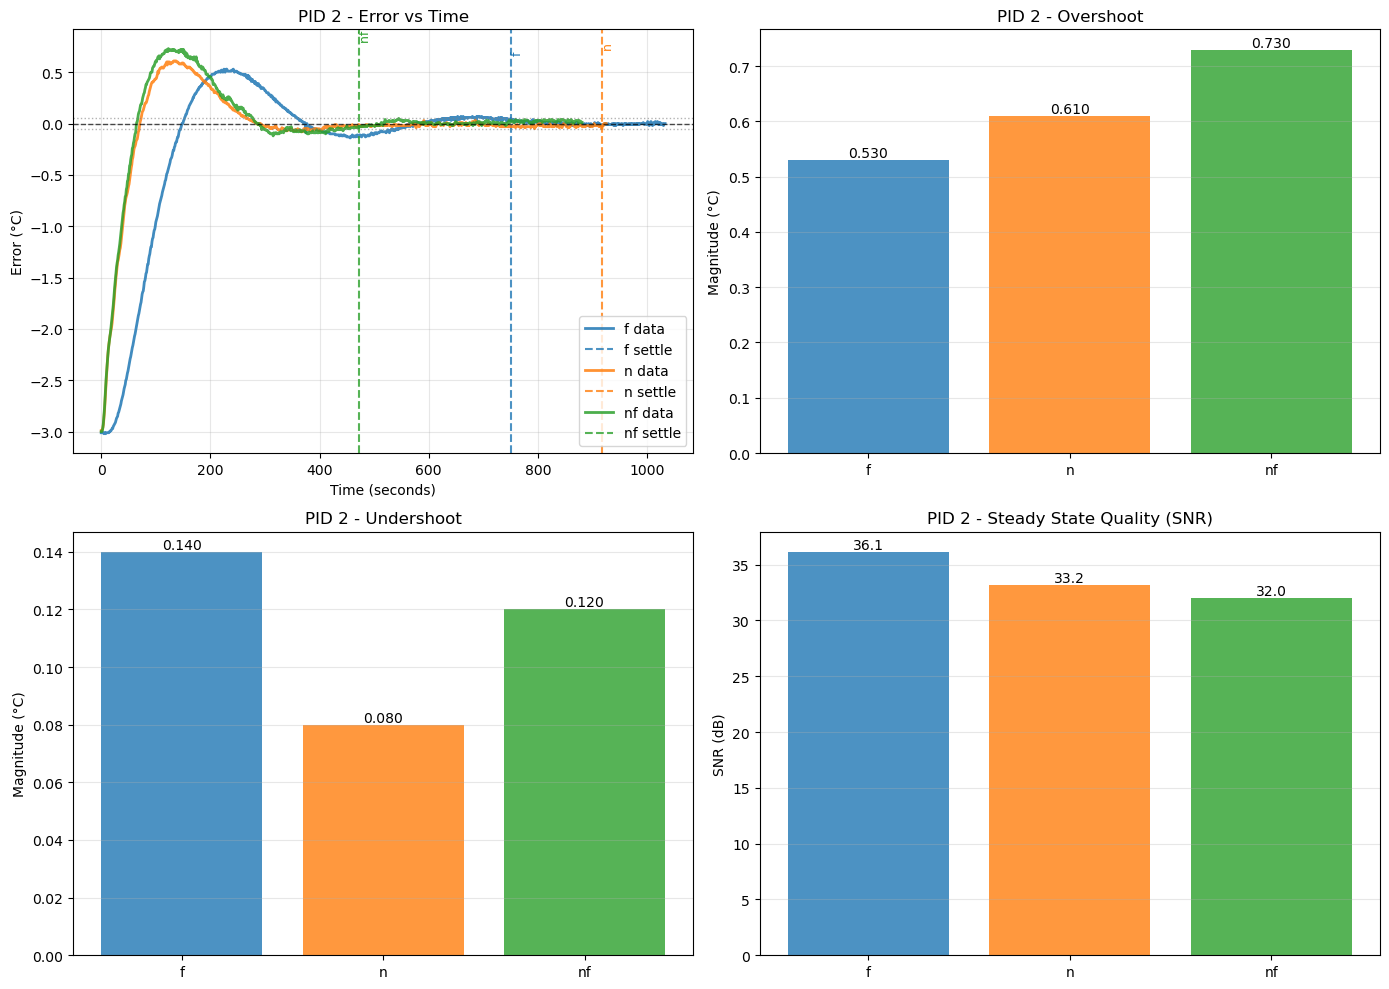

In [347]:
plot_thermal_analysis(peltiers, tolerance=tolerance)

Loaded: 1234 f 1.93_2026-05-08T10_44_24.464Z.csv (Initial: 1.93°C, Setpoint: 4.93°C)
Loaded: 1234 n 2.00_2026-05-08T12_05_43.546Z.csv (Initial: 2.0°C, Setpoint: 5.0°C)
Loaded: 1234 nf 2.00_2026-05-05T17_30_20.147Z.csv (Initial: 2.0°C, Setpoint: 5.0°C)


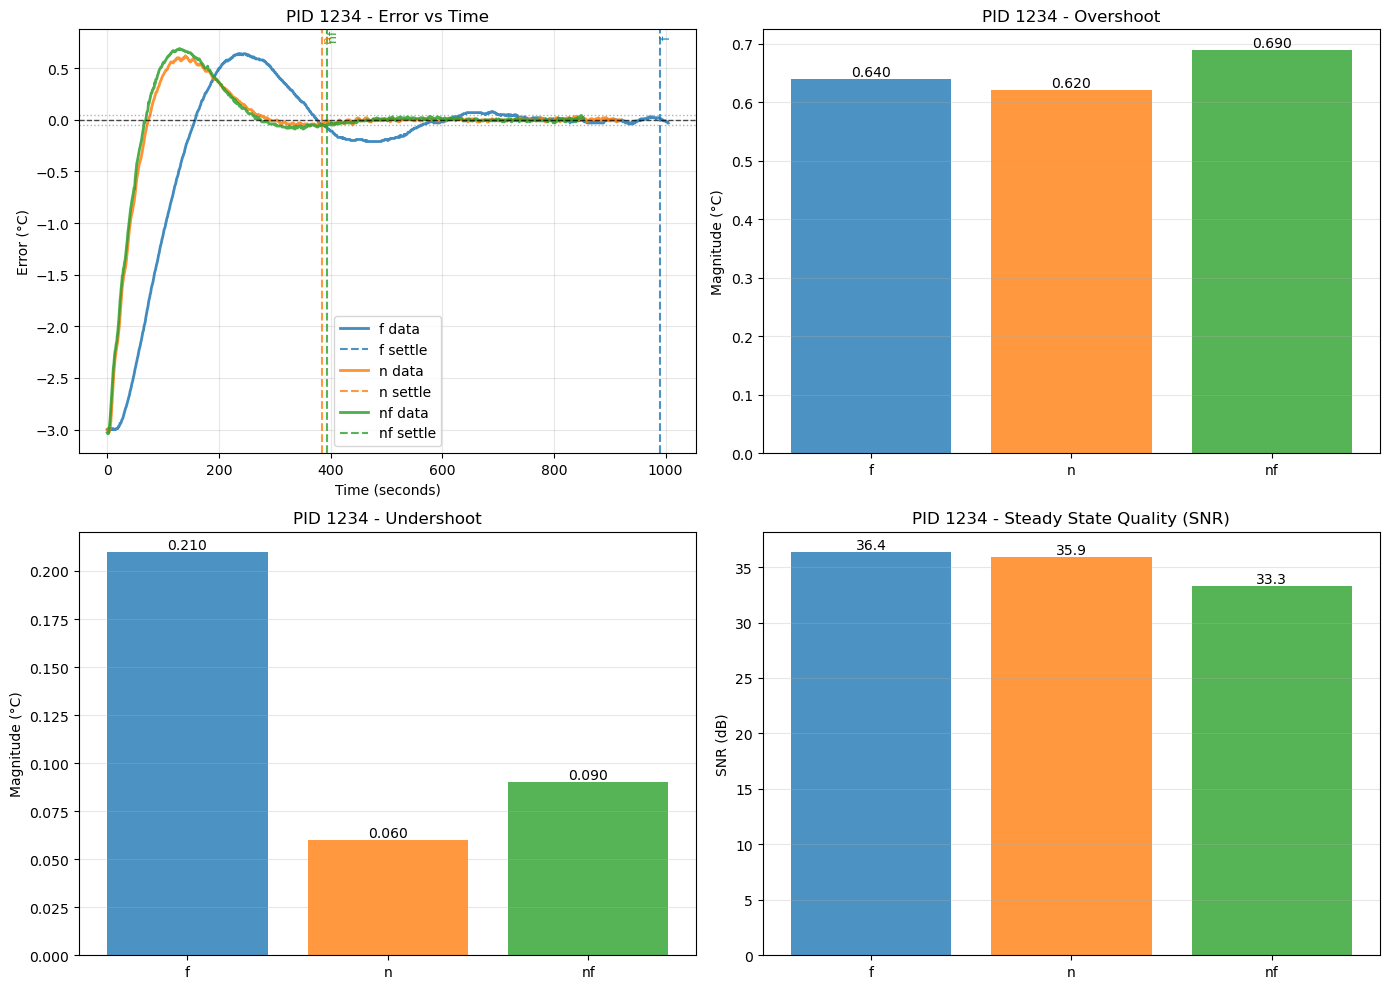

Loaded: temperature_data_2026-05-05T11_16_38.917Z.csv (Initial: 3.0°C, Setpoint: 6.0°C)
Loaded: temperature_data_2026-05-05T13_59_49.371Z.csv (Initial: 2.86°C, Setpoint: 5.859999999999999°C)
Loaded: 123 nf 2.80_2026-05-05T16_56_51.104Z.csv (Initial: 2.8°C, Setpoint: 5.8°C)


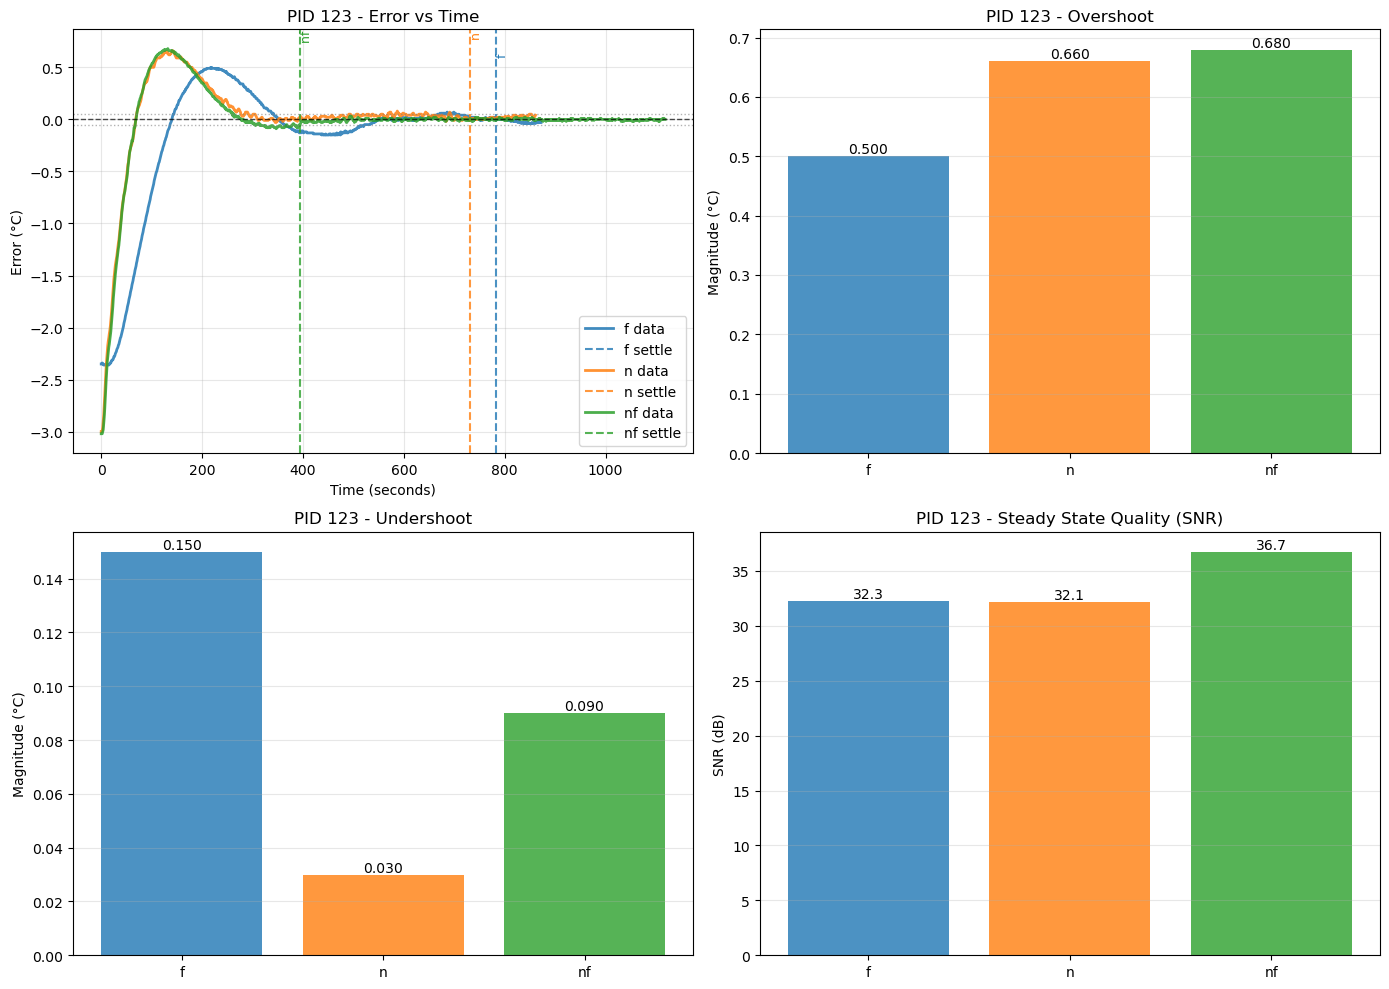

Loaded: temperature_data_2026-05-05T12_28_27.132Z.csv (Initial: 4.0°C, Setpoint: 7.0°C)
Loaded: temperature_data_2026-05-05T14_53_24.701Z.csv (Initial: 3.1°C, Setpoint: 6.1°C)
Loaded: 134 nf 2.43_2026-05-05T18_22_13.792Z.csv (Initial: 2.43°C, Setpoint: 5.43°C)


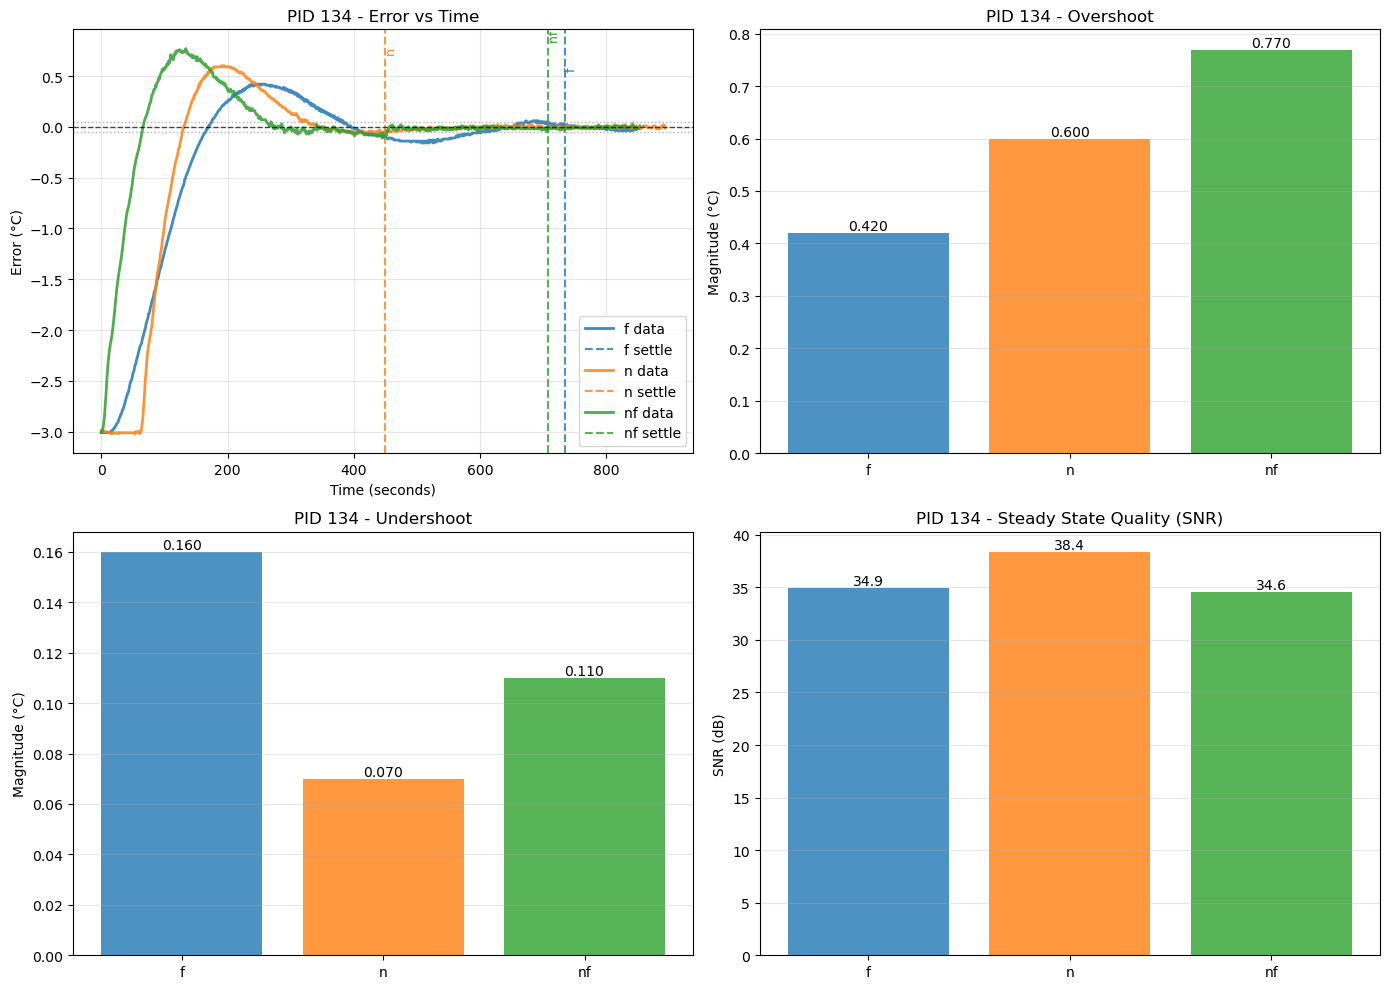

Loaded: temperature_data_2026-05-05T11_53_59.621Z.csv (Initial: 6.35°C, Setpoint: 9.35°C)
Loaded: temperature_data_2026-05-05T14_32_54.965Z.csv (Initial: 4.2°C, Setpoint: 7.2°C)
Loaded: 124 nf 5.08_2026-05-05T17_51_08.055Z.csv (Initial: 5.08°C, Setpoint: 8.08°C)


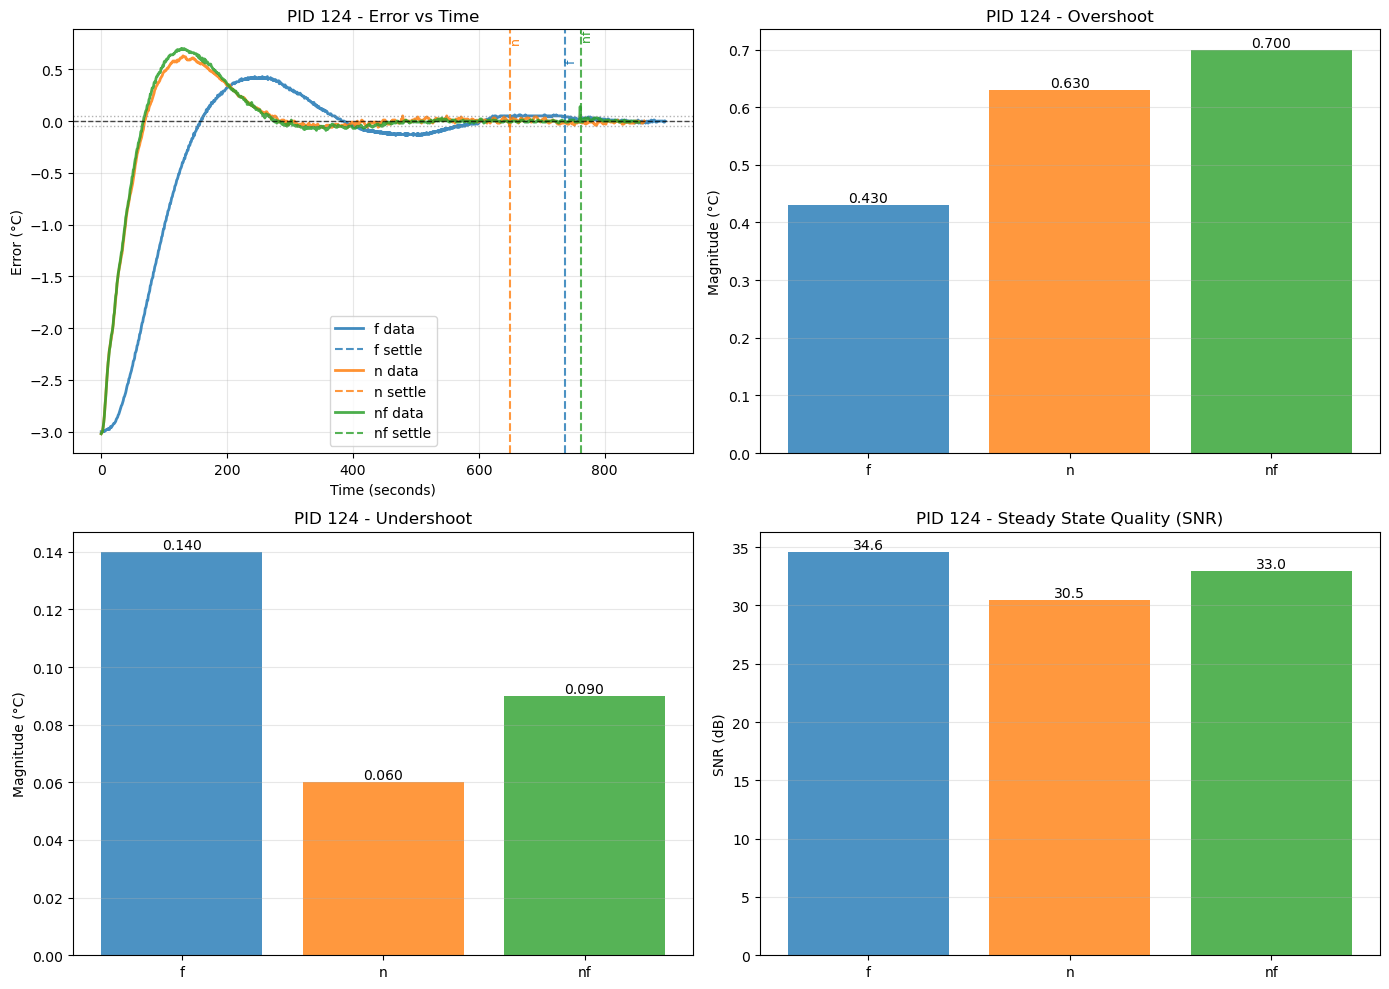

Loaded: temperature_data_2026-05-05T13_10_14.401Z.csv (Initial: 11.6°C, Setpoint: 14.6°C)
Loaded: 234 n 10.00_2026-05-05T15_38_11.384Z.csv (Initial: 10.0°C, Setpoint: 13.0°C)
Loaded: 234 nf 10.24_2026-05-05T18_45_58.271Z.csv (Initial: 10.24°C, Setpoint: 13.24°C)


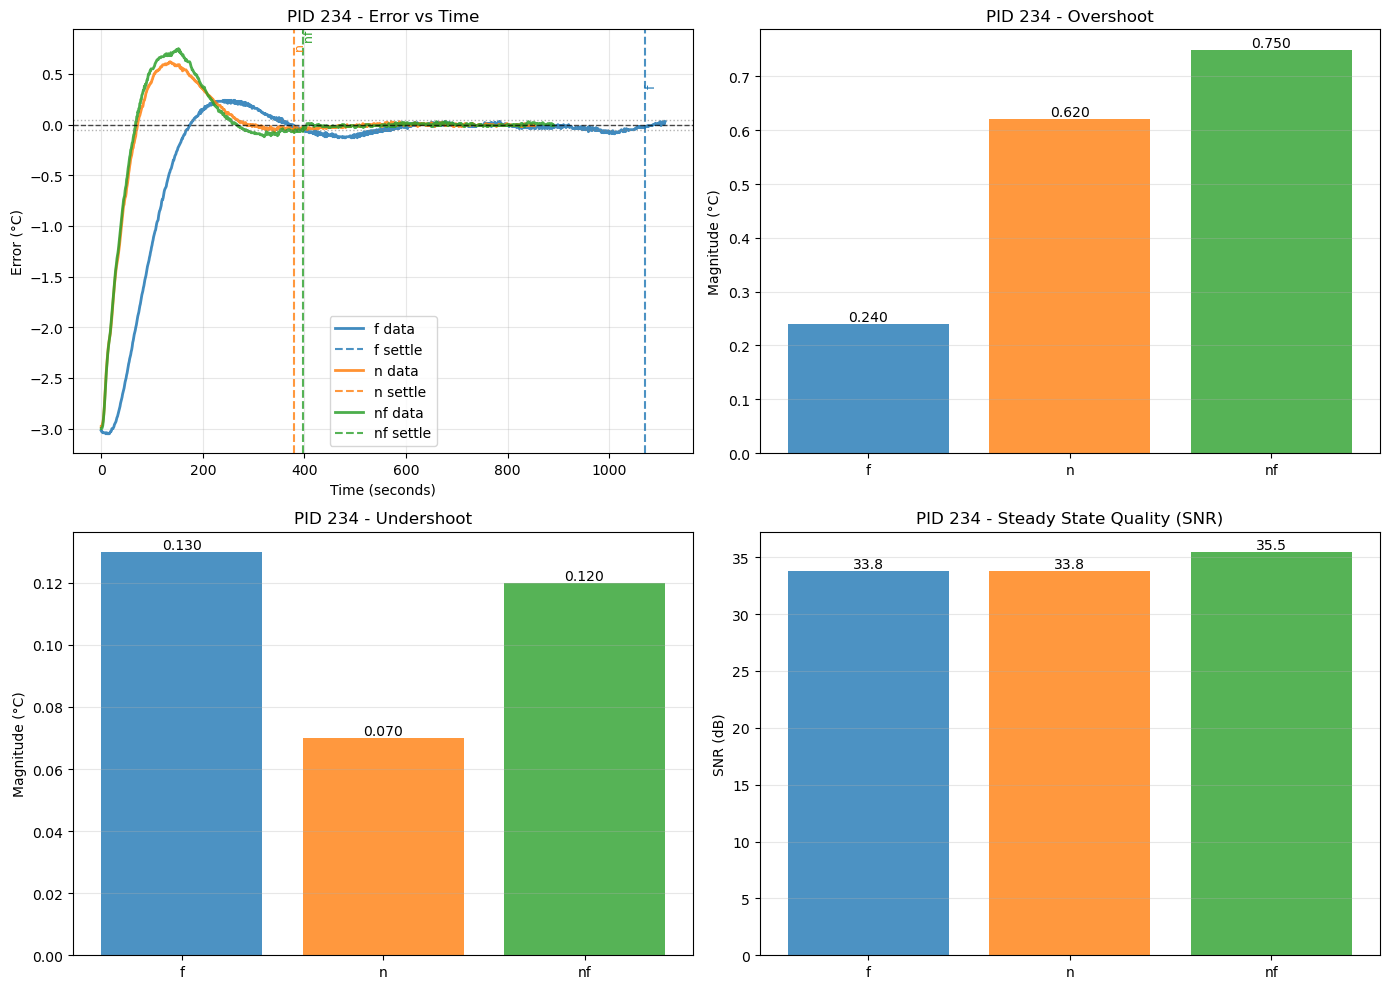

Loaded: 1 f 10.50_2026-05-06T07_49_15.218Z.csv (Initial: 10.5°C, Setpoint: 13.5°C)
Loaded: 1 n 9.70_2026-05-06T08_20_20.163Z.csv (Initial: 9.7°C, Setpoint: 12.7°C)
Loaded: 1 nf 9.30_2026-05-06T08_53_03.382Z.csv (Initial: 9.3°C, Setpoint: 12.3°C)


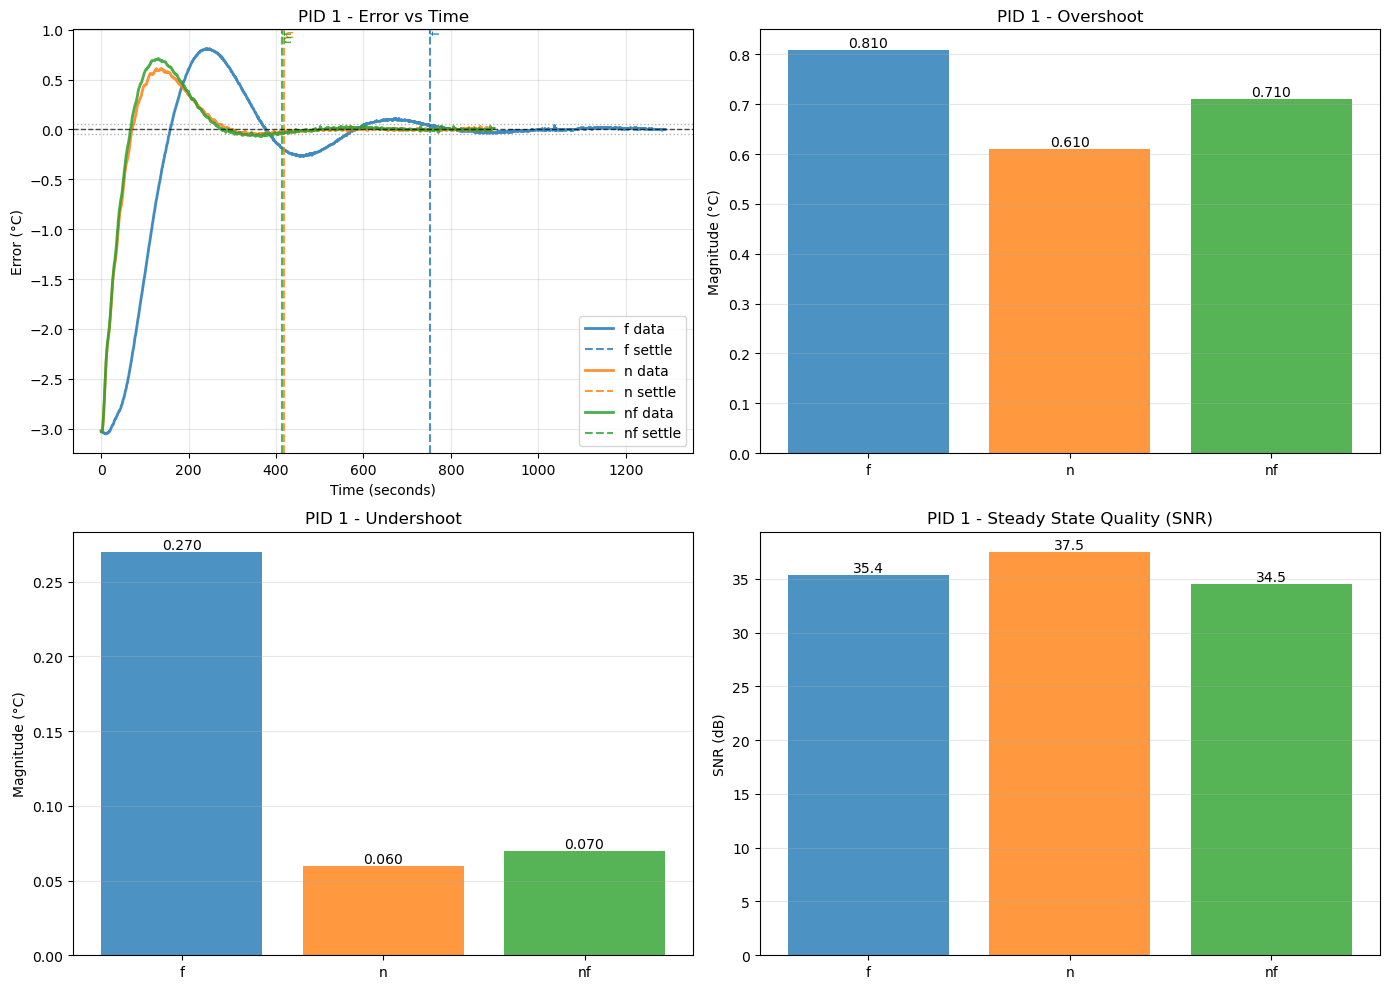

Loaded: 2 f 16.78_2026-05-06T10_45_50.690Z.csv (Initial: 16.78°C, Setpoint: 19.78°C)
Loaded: 2 n 16.80_2026-05-06T11_17_11.442Z.csv (Initial: 16.8°C, Setpoint: 19.8°C)
Loaded: 2 nf 16.34_2026-05-06T10_13_57.141Z.csv (Initial: 16.34°C, Setpoint: 19.34°C)


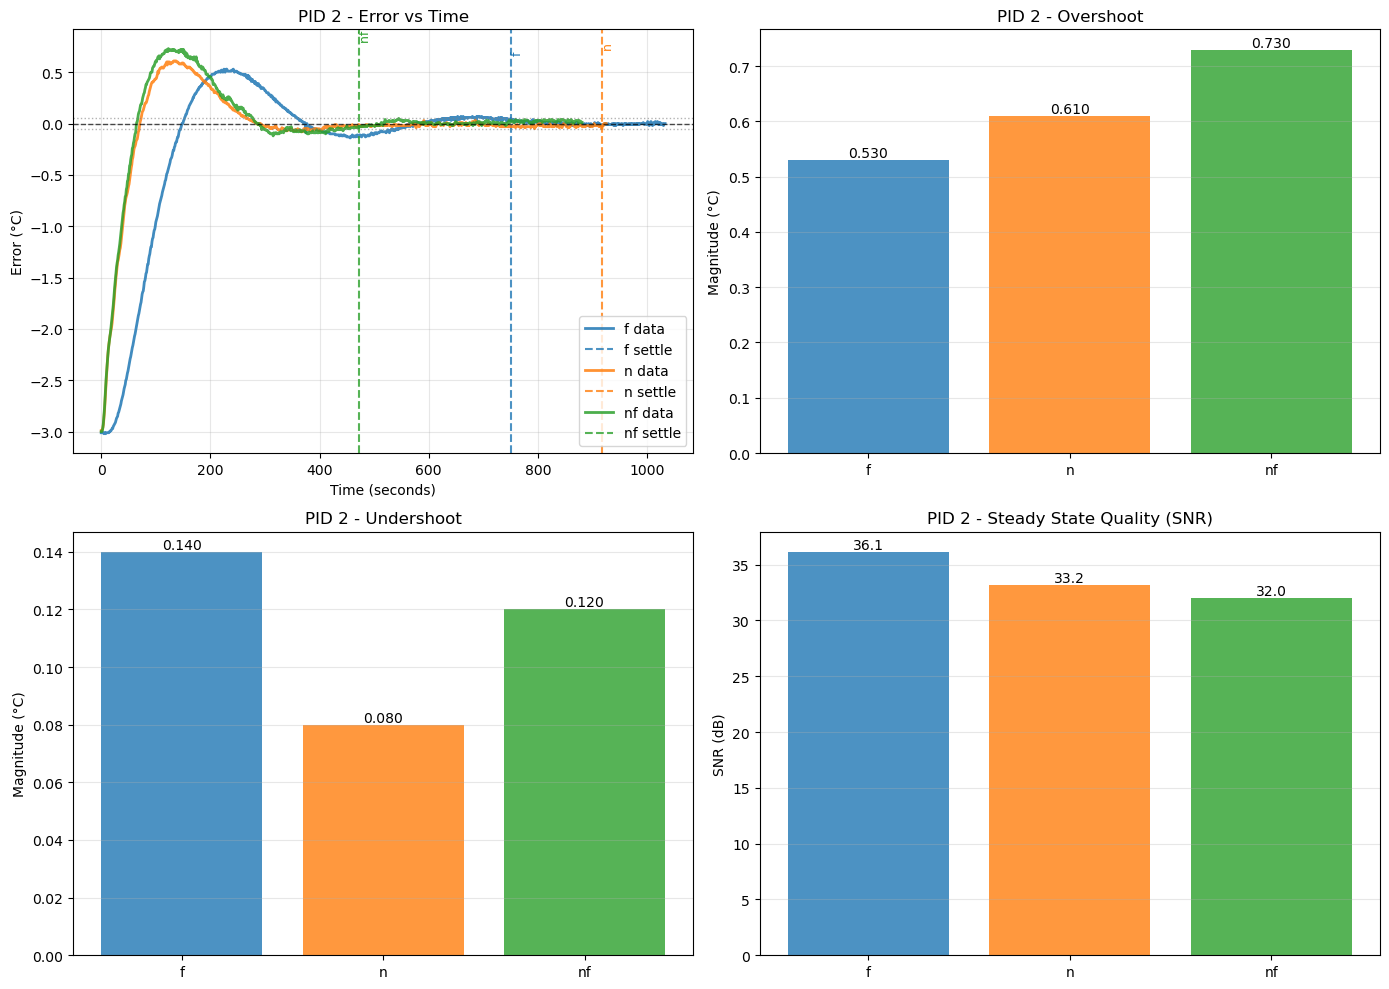

In [348]:
peltiers = ["1234", "123", "134", "124", "234", "1", "2"]

for peltier in peltiers:
    plot_thermal_analysis(peltier, tolerance=tolerance)